# Notebook 2 — Entraînement du CNN Baseline
**Projet** : Classification d'images médicales — Détection de pneumonie  
**Architecture** : CNN baseline (3 blocs Conv+ReLU+MaxPool, Dense(128), Sigmoid)  
**Optimiseur** : Adam | **Perte** : Binary Cross-Entropy | **Époques** : 20 max

In [2]:
import os
import sys

# On remonte d'un niveau pour accéder à src/
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.dataset import get_dataloaders
from src.model import CNNBaseline

# Vérification du device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')

Device utilisé : cuda


## 1. Paramètres d'entraînement (conformes au PDF)

In [3]:
BATCH_SIZE    = 32
EPOCHS        = 20
LEARNING_RATE = 1e-3
DROPOUT_RATE  = 0.5
PATIENCE      = 5

CHECKPOINT_PATH = os.path.join('..', 'outputs', 'checkpoints', 'best_model.pt')
FIGURES_PATH    = os.path.join('..', 'outputs', 'figures')

print(f'Batch size    : {BATCH_SIZE}')
print(f'Époques max   : {EPOCHS}')
print(f'Learning rate : {LEARNING_RATE}')
print(f'Dropout       : {DROPOUT_RATE}')
print(f'Early stopping patience : {PATIENCE}')

Batch size    : 32
Époques max   : 20
Learning rate : 0.001
Dropout       : 0.5
Early stopping patience : 5


## 2. Chargement des données

In [4]:
train_loader, val_loader, _ = get_dataloaders(batch_size=BATCH_SIZE)
print(f'Batches train : {len(train_loader)}')
print(f'Batches val   : {len(val_loader)}')

images, labels = next(iter(train_loader))
print(f'Shape batch   : {images.shape}')
print(f'Classes       : {train_loader.dataset.classes}')

Batches train : 163
Batches val   : 1
Shape batch   : torch.Size([32, 3, 224, 224])
Classes       : ['NORMAL', 'PNEUMONIA']


## 3. Initialisation du modèle, de la perte et de l'optimiseur

In [5]:
model     = CNNBaseline(dropout_rate=DROPOUT_RATE).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Paramètres du modèle : {total_params:,}')
print(model)

Paramètres du modèle : 12,938,561
CNNBaseline(
  (bloc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 4. Boucle d'entraînement

In [6]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss  = float('inf')
patience_count = 0

for epoch in range(1, EPOCHS + 1):

    # --- Phase TRAIN ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        preds          = (outputs >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)

    avg_train_loss = train_loss / train_total
    avg_train_acc  = train_correct / train_total

    # --- Phase VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs     = model(images)
            loss        = criterion(outputs, labels)
            val_loss   += loss.item() * images.size(0)
            preds       = (outputs >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)

    avg_val_loss = val_loss / val_total
    avg_val_acc  = val_correct / val_total

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_acc'].append(avg_val_acc)

    print(f'Époque {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | '
          f'Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss  = avg_val_loss
        patience_count = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f'  --> Meilleur modèle sauvegardé (val_loss={best_val_loss:.4f})')
    else:
        patience_count += 1
        print(f'  --> Pas d amélioration ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print('Early stopping déclenché.')
            break

print('\nEntraînement terminé !')

Époque 01/20 | Train Loss: 0.3708 | Train Acc: 0.8671 | Val Loss: 0.9754 | Val Acc: 0.5625
  --> Meilleur modèle sauvegardé (val_loss=0.9754)
Époque 02/20 | Train Loss: 0.1773 | Train Acc: 0.9335 | Val Loss: 0.7043 | Val Acc: 0.6250
  --> Meilleur modèle sauvegardé (val_loss=0.7043)
Époque 03/20 | Train Loss: 0.1479 | Train Acc: 0.9433 | Val Loss: 0.4320 | Val Acc: 0.7500
  --> Meilleur modèle sauvegardé (val_loss=0.4320)
Époque 04/20 | Train Loss: 0.1395 | Train Acc: 0.9475 | Val Loss: 0.3239 | Val Acc: 0.8125
  --> Meilleur modèle sauvegardé (val_loss=0.3239)
Époque 05/20 | Train Loss: 0.1283 | Train Acc: 0.9523 | Val Loss: 0.3651 | Val Acc: 0.8125
  --> Pas d amélioration (1/5)
Époque 06/20 | Train Loss: 0.1155 | Train Acc: 0.9576 | Val Loss: 0.6159 | Val Acc: 0.6875
  --> Pas d amélioration (2/5)
Époque 07/20 | Train Loss: 0.1078 | Train Acc: 0.9622 | Val Loss: 0.5059 | Val Acc: 0.6875
  --> Pas d amélioration (3/5)
Époque 08/20 | Train Loss: 0.1065 | Train Acc: 0.9590 | Val Loss: 

## 5. Courbes Loss et Accuracy

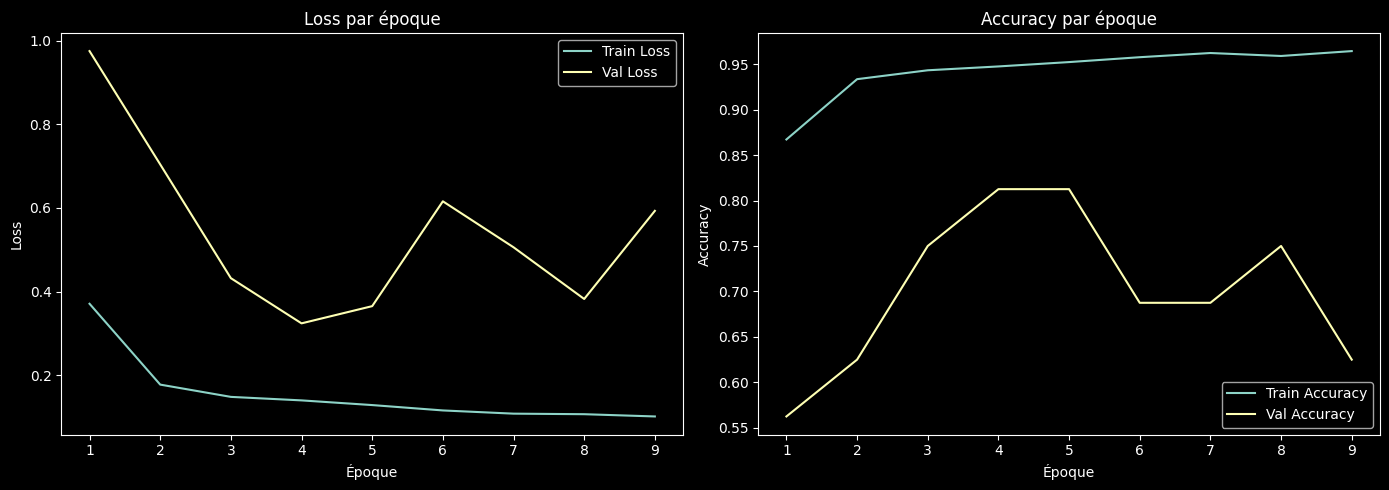

Courbes sauvegardées.


In [7]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss')
ax1.set_title('Loss par époque')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy')
ax2.plot(epochs_range, history['val_acc'],   label='Val Accuracy')
ax2.set_title('Accuracy par époque')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'courbes_entrainement.png'))
plt.show()
print('Courbes sauvegardées.')

## Conclusion
- Le modèle CNN baseline a été entraîné avec Adam (lr=1e-3) et Binary Cross-Entropy
- L'early stopping évite le sur-apprentissage
- Le meilleur modèle est sauvegardé dans `outputs/checkpoints/best_model.pt`
- Les oscillations du val set sont dues à sa très petite taille (16 images)
- Les vraies performances seront mesurées dans le notebook 03 sur le test set